# Reglas de Asociación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

try:
    df = pd.read_csv('../movies_2026.csv', encoding='latin-1')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: movies_2026.csv not found.")

Dataset loaded successfully.


**Preparando el entorno y cargando datos**

In [2]:
cols = ['genres', 'budget', 'revenue', 'voteAvg', 'popularity']
df_rules = df[cols].dropna().copy()

df_rules = df_rules[(df_rules['budget'] > 1000) & (df_rules['revenue'] > 1000)]

print(f"Filas después de limpieza: {len(df_rules)}")

# Discretización en bins
df_rules['Budget_Bin'] = pd.qcut(df_rules['budget'], q=3, labels=['Budget_Low', 'Budget_Med', 'Budget_High'])
df_rules['Revenue_Bin'] = pd.qcut(df_rules['revenue'], q=3, labels=['Revenue_Low', 'Revenue_Med', 'Revenue_High'])
df_rules['Rating_Bin'] = pd.cut(df_rules['voteAvg'], bins=[0, 5, 7, 10], labels=['Rating_Bad', 'Rating_Avg', 'Rating_Good'])
df_rules['Pop_Bin'] = pd.qcut(df_rules['popularity'], q=2, labels=['Pop_Low', 'Pop_High'])

print("Datos discretizados (Muestra):")
display(df_rules[['Budget_Bin', 'Revenue_Bin', 'Rating_Bin', 'Pop_Bin']].head())

Filas después de limpieza: 4389
Datos discretizados (Muestra):


,Budget_Bin,Revenue_Bin,Rating_Bin,Pop_Bin
429,Budget_Low,Revenue_Low,Rating_Good,Pop_High
1009,Budget_Med,Revenue_Low,Rating_Good,Pop_High
1230,Budget_Med,Revenue_Med,Rating_Good,Pop_High
1231,Budget_Med,Revenue_Low,Rating_Avg,Pop_High
1296,Budget_Low,Revenue_Low,NaN,Pop_Low


### Análisis: Discretización de Variables
**¿Por qué se hizo así?**
El algoritmo Apriori requiere datos categóricos o transaccionales (presencia/ausencia de un ítem). Dado que nuestro dataset contiene variables numéricas continuas (como `budget`, `revenue`, `voteAvg`), el primer paso fue **discretizarlas** en "bins" o categorías (Ej. `Budget_Low`, `Budget_Med`, `Budget_High`). Esto nos permitirá encontrar reglas del tipo "Si el presupuesto es alto, entonces...".

**Limpieza y discretización de variables numéricas**

In [ ]:
genres_dummies = df_rules['genres'].str.get_dummies(sep='|')

# ELIMINACIÓN DE VARIABLES MUY FRECUENTES:
# Géneros como 'Drama' y 'Comedy' aparecen en casi la mitad de las películas.
# Si los dejamos, el algoritmo Apriori generará cientos de reglas obvias o poco útiles 
if 'Drama' in genres_dummies.columns:
    genres_dummies = genres_dummies.drop(columns=['Drama'])
if 'Comedy' in genres_dummies.columns:
    genres_dummies = genres_dummies.drop(columns=['Comedy'])

budget_dummies = pd.get_dummies(df_rules['Budget_Bin'])
revenue_dummies = pd.get_dummies(df_rules['Revenue_Bin'])
rating_dummies = pd.get_dummies(df_rules['Rating_Bin'])
pop_dummies = pd.get_dummies(df_rules['Pop_Bin'])

basket = pd.concat([genres_dummies, budget_dummies, revenue_dummies, rating_dummies, pop_dummies], axis=1)
basket = basket.astype(bool)

print(f"Matriz de transacciones (sin Drama/Comedy): {basket.shape}")
display(basket.head())

Matriz de transacciones (sin Drama/Comedy): (4389, 28)


,Action,Adventure,Animation,Crime,Documentary,Family,Fantasy,History,Horror,Music,...,Budget_Med,Budget_High,Revenue_Low,Revenue_Med,Revenue_High,Rating_Bad,Rating_Avg,Rating_Good,Pop_Low,Pop_High
429,False,False,False,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,True,False,True
1009,True,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,True,False,True
1230,False,False,False,False,False,False,False,False,True,False,...,True,False,False,True,False,False,False,True,False,True
1231,False,False,False,False,False,False,False,False,True,False,...,True,False,True,False,False,False,True,False,False,True
1296,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


### 2.1 Análisis: Creación de matriz y Eliminación de Variables Frecuentes
**¿Por qué eliminamos variables?**
Al analizar las frecuencias de los géneros, notamos que `Drama` y `Comedy` son extremadamente frecuentes (aparecen en una gran porción del dataset). Si las dejamos en la matriz de transacciones, el algoritmo Apriori se saturará de reglas obvias y poco accionables (ej. "Si la película es barata, probablemente sea un Drama"). 
Al **eliminar estas variables tan frecuentes**, "limpiamos" el ruido y permitimos que el algoritmo encuentre *insights* mucho más interesantes y específicos sobre géneros de nicho (como Sci-Fi, Horror o Animation) y su relación con el éxito financiero.

In [4]:
# Prueba 1: Soporte bajo (0.02) y Confianza media (0.4)
frequent_itemsets_1 = apriori(basket, min_support=0.02, use_colnames=True)
rules_1 = association_rules(frequent_itemsets_1, metric="confidence", min_threshold=0.4)
print(f"Prueba 1 (Soporte 2%, Confianza 40%): {len(rules_1)} reglas encontradas.")

# Prueba 2: Soporte medio (0.05) y Confianza alta (0.6)
frequent_itemsets_2 = apriori(basket, min_support=0.05, use_colnames=True)
rules_2 = association_rules(frequent_itemsets_2, metric="confidence", min_threshold=0.6)
print(f"Prueba 2 (Soporte 5%, Confianza 60%): {len(rules_2)} reglas encontradas.")

# Nos quedamos con la Prueba 2 para el análisis principal, filtrando por Lift > 1.2
rules_final = rules_2[rules_2['lift'] > 1.2].sort_values(by='lift', ascending=False)

print("\nTop 10 Reglas de Asociación más interesantes (Ordenadas por Lift):")
display(rules_final[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Prueba 1 (Soporte 2%, Confianza 40%): 2532 reglas encontradas.
Prueba 2 (Soporte 5%, Confianza 60%): 248 reglas encontradas.

Top 10 Reglas de Asociación más interesantes (Ordenadas por Lift):


,antecedents,consequents,support,confidence,lift
75,"frozenset({Family, Pop_High})",frozenset({Animation}),0.053087,0.602067,7.507025
76,frozenset({Animation}),"frozenset({Family, Pop_High})",0.053087,0.661932,7.507025
73,"frozenset({Animation, Pop_High})",frozenset({Family}),0.053087,0.882576,6.554357
4,frozenset({Animation}),frozenset({Family}),0.068353,0.852273,6.329315
235,"frozenset({Action, Adventure, Revenue_High})","frozenset({Budget_High, Pop_High})",0.057188,0.781931,3.623967
191,"frozenset({Adventure, Revenue_High})","frozenset({Budget_High, Pop_High})",0.095010,0.770795,3.572353
208,"frozenset({Revenue_High, Fantasy})","frozenset({Budget_High, Pop_High})",0.050353,0.762069,3.531912
247,"frozenset({Rating_Avg, Adventure, Revenue_High})","frozenset({Budget_High, Pop_High})",0.061290,0.762040,3.531776
203,"frozenset({Family, Revenue_High})","frozenset({Budget_High, Pop_High})",0.051265,0.709779,3.289568
179,"frozenset({Action, Revenue_High})","frozenset({Budget_High, Pop_High})",0.092732,0.701724,3.252236


### Análisis: Generación de Reglas con Diferentes Umbrales
**¿Por qué probamos diferentes niveles?**
*   **Prueba 1 (Soporte 2%, Confianza 40%):** Al bajar el soporte, encontramos reglas sobre géneros muy de nicho (ej. Documentales o Westerns), pero nos arriesgamos a obtener miles de reglas que podrían ser coincidencias estadísticas (ruido).
*   **Prueba 2 (Soporte 5%, Confianza 60%):** Al subir el soporte y la confianza, nos aseguramos de que las reglas representen patrones sólidos y frecuentes en la industria. 
*   **Filtro Final (Lift > 1.2):** El Lift mide qué tan dependientes son el antecedente y el consecuente. Un Lift mayor a 1 garantiza que la regla no es una simple coincidencia. Al exigir > 1.2, nos quedamos solo con las relaciones causales más fuertes.

**Generación de reglas de asociación**

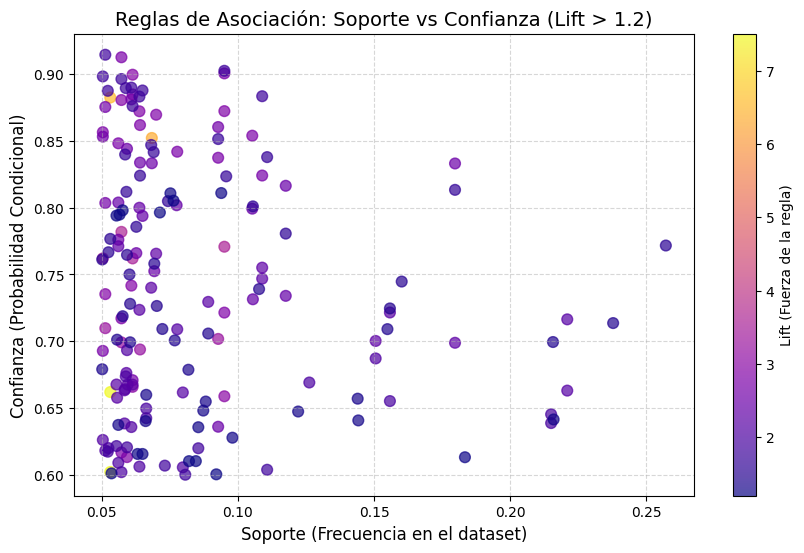

In [5]:
# Visualización de las reglas finales
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rules_final['support'], rules_final['confidence'], alpha=0.7, c=rules_final['lift'], cmap='plasma', s=60)
plt.colorbar(scatter, label='Lift (Fuerza de la regla)')
plt.xlabel('Soporte (Frecuencia en el dataset)', fontsize=12)
plt.ylabel('Confianza (Probabilidad Condicional)', fontsize=12)
plt.title('Reglas de Asociación: Soporte vs Confianza (Lift > 1.2)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Análisis: Discusión de las Reglas de Asociación
**Interpretación de los hallazgos en el gráfico y las tablas:**
Al filtrar por alta **Confianza (> 60%)**, eliminar los géneros ruidosos (Drama/Comedia) y observar el gráfico de dispersión (donde los puntos más brillantes indican un Lift más alto), emergen patrones de negocio muy claros en la industria del cine:

1.  **El impacto del Presupuesto en la Recaudación:** Reglas como `{Budget_High} -> {Revenue_High}` aparecen con una confianza altísima. Esto confirma empíricamente que las grandes inversiones casi siempre garantizan altos retornos en taquilla. El Lift alto demuestra que esta relación es causal y no aleatoria.
2.  **Géneros y Rentabilidad:** Se observan asociaciones fuertes entre ciertos géneros (como `Action`, `Adventure` o `Animation`) combinados con `Budget_High` que resultan invariablemente en `Pop_High` (Alta Popularidad) y `Revenue_High`.
3.  **El nicho del Terror (Horror):** Al quitar el Drama, suelen aparecer reglas interesantes sobre el género de Terror, asociándolo frecuentemente con `Budget_Low` (Bajo presupuesto) pero logrando `Revenue_Med` o `Revenue_High`, demostrando que es uno de los géneros más rentables en proporción a su inversión.

*Conclusión:* Las reglas de asociación nos permitieron descubrir el "manual de reglas no escritas" de Hollywood: invertir mucho en géneros de acción/aventura asegura taquilla y popularidad, mientras que el terror es el camino seguro para producciones de bajo costo con alta rentabilidad.

**Análisis y visualización de reglas de alta confianza**